In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset
import numpy as np
import xisf
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import matplotlib.pyplot as plt
import pandas as pd
import copy
from collections import Counter
from torch.optim.lr_scheduler import ReduceLROnPlateau
import datetime

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.xpu.is_available():
    device = torch.device("xpu")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
from tqdm.notebook import tqdm


Using device: cuda


In [2]:
# --- DEBUGGING CELL ---
# Run this to verify XISF value ranges BEFORE training
import os
from pathlib import Path
import numpy as np
import xisf
import matplotlib.pyplot as plt
import cv2

# Ensure DATA_ROOT is defined
if 'DATA_ROOT' not in locals():
    DATA_ROOT = Path(os.getcwd()) / 'training_data'
    print(f"Defined DATA_ROOT as {DATA_ROOT}")

if DATA_ROOT and DATA_ROOT.exists():
    try:
        # Find first XISF
        sample_iter = DATA_ROOT.rglob('*.xisf')
        sample_file = next(sample_iter, None)
        
        if sample_file:
            print(f"Inspecting sample: {sample_file}")
            
            # Load raw data using xisf library directly
            raw_data = xisf.XISF.read(str(sample_file))
            arr = np.asarray(raw_data)
            print(f"Raw Shape: {arr.shape}")
            print(f"Raw Type: {arr.dtype}")
            print(f"Raw Min: {arr.min()}, Max: {arr.max()}, Mean: {arr.mean()}")
            
            # Test xisf_loader (Ensure definition exists or define locally)
            if 'xisf_loader' in locals():
                loaded = xisf_loader(str(sample_file))
                print(f"Loaded Shape: {loaded.shape}")
                print(f"Loaded Min: {loaded.min()}, Max: {loaded.max()}, Mean: {loaded.mean()}")
                
                # Test Pre-processing logic
                resized = cv2.resize(loaded, (224, 224))
                if resized.ndim == 2: resized = resized[..., np.newaxis]
                
                # Check if clipping is destroying it
                clipped = np.clip(resized, 0, 1.0)
                print(f"Clipped Max (Should be <= 1.0): {clipped.max()}")
                
                if loaded.max() > 1.0:
                     print("!! WARNING !! Input data > 1.0. Clipping to 1.0 would destroy data!")
                     print("Applying Normalization Fix (Div by 65535)...")
                     norm_ver = resized / 65535.0
                     print(f"Normalized Max: {norm_ver.max()}")
                     
                else:
                     norm_ver = resized
                     
                uint8_ver = (np.clip(norm_ver, 0, 1.0) * 255).astype(np.uint8)
                print(f"Uint8 Max: {uint8_ver.max()}")
                
                # Visualize
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1); plt.title('Raw Loaded'); plt.imshow(loaded.squeeze(), cmap='gray')
                plt.subplot(1, 2, 2); plt.title('Uint8 Pre-processed'); plt.imshow(uint8_ver.squeeze(), cmap='gray')
                plt.show()
            else:
                print("xisf_loader not defined yet. Run imports/setup cell first.")
        else:
            print("No .xisf files found in DATA_ROOT")
            
    except Exception as e:
        print(f"Error in debug: {e}")
else:
    print(f"DATA_ROOT not found: {DATA_ROOT}")

Defined DATA_ROOT as /Storage/Files/practicalML/gitlab/practicalml/training_data
Inspecting sample: /Storage/Files/practicalML/gitlab/practicalml/training_data/wind/2024-10-14_01-30-04__-0.00_300.00s_0121_star_26_x7307_y3296_B_linear.xisf
Raw Shape: (256, 256, 1)
Raw Type: uint16
Raw Min: 10266, Max: 65535, Mean: 11254.818222045898
xisf_loader not defined yet. Run imports/setup cell first.


In [3]:
def xisf_loader(path: str) -> np.ndarray:
    """
    Loads a .xisf file, ensures it's a float array,
    and returns it as a NumPy array in (H, W, C) format.
    """
    try:
        # Load the XISF data
        data = xisf.XISF.read(path)
        
        # .copy() creates a new, writable array in memory for PyTorch
        data = np.asarray(data, dtype=np.float32).copy()

        # PyTorch's ToTensor() transform expects (H, W, C)
        # 1. If data is 2D (H, W), add a channel dim -> (H, W, 1)
        if data.ndim == 2:
            data = data[..., np.newaxis]
        
        # 2. If data is (H, W, 1) or (H, W, 3), it's already correct.
        
        # 3. If data is (C, H, W), transpose it -> (H, W, C)
        elif data.ndim == 3 and data.shape[0] in [1, 3]:
             data = data.transpose((1, 2, 0))

        return data

    except Exception as e:
        print(f"Error loading {path}: {e}")
        return None

def detect_color_channels(data_root_path: Path) -> int:
    """
    Detects if the images in the ImageFolder are 1-channel or 3-channel.
    """
    print(f"Detecting color channels in {data_root_path}...")
    try:
        # Find the first class sub-directory
        first_class_dir = next(p for p in data_root_path.iterdir() if p.is_dir())
        
        # Find the first .xisf file in that directory
        first_xisf_file = next(first_class_dir.rglob('*.xisf'))
        
        print(f"  Checking sample file: {first_xisf_file.name}")
        
        # Load it using our loader
        sample_data = xisf_loader(str(first_xisf_file))
        
        if sample_data.ndim == 3:
            channels = sample_data.shape[2]
            print(f"  Detected {channels} channels.")
            return channels
        elif sample_data.ndim == 2:
            print("  Detected 1 channel (grayscale).")
            return 1
            
    except Exception as e:
        print(f"  !! Warning: Could not detect channels: {e}. Defaulting to 3. !!")
        return 3

# --- CUSTOM RAM DATASET ---

# --- OPTIMIZED RAM DATASET ---

# --- OPTIMIZED RAM DATASET (With Progress Bar) ---

# --- OPTIMIZED RAM DATASET (With Normalization Fix) ---
class PreloadedDataset(Dataset):
    def __init__(self, root, loader, transform=None, is_valid_file=None):
        self.root = Path(root)
        self.loader = loader
        self.transform = transform
        self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = []
        self.targets = []
        
        print(f"Scanning files in {self.root}...")
        for target_class in self.classes:
            class_index = self.class_to_idx[target_class]
            target_dir = self.root / target_class
            if not target_dir.is_dir(): continue
            
            for root, _, fnames in sorted(os.walk(target_dir, followlinks=True)):
                for fname in sorted(fnames):
                    path = os.path.join(root, fname)
                    if is_valid_file and not is_valid_file(path): continue
                    self.samples.append(path)
                    self.targets.append(class_index)
                    
        print(f"Found {len(self.samples)} images. Loading to RAM (Resize 224x224, 16-bit->8-bit Norm)...")
        
        # Internal loader wrapper
        def load_and_process(path):
            img = self.loader(path)
            if img is None: return None
            
            # Resize first (keep float range)
            import cv2 
            img_resized = cv2.resize(img, (224, 224))
            if img_resized.ndim == 2: 
                img_resized = img_resized[..., np.newaxis]
            
            # --- NORMALIZATION FIX ---
            # If data is 16-bit (0-65535), divide by 65535 to get 0-1
            if img_resized.max() > 1.0:
                img_norm = img_resized / 65535.0
            else:
                img_norm = img_resized
            
            # Now safe to clip and convert to uint8 (0-255)
            img_uint8 = (np.clip(img_norm, 0, 1.0) * 255).astype(np.uint8)
            return img_uint8
            
        self.images = []
        from concurrent.futures import ThreadPoolExecutor
        from tqdm.notebook import tqdm
        
        with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
             self.images = list(tqdm(executor.map(load_and_process, self.samples), total=len(self.samples), desc="Loading & Normalizing"))
        
        # Filter Nones
        self.images = [x for x in self.images if x is not None]
        print(f"Successfully loaded {len(self.images)} images (Uint8 Cached).")

    def __getitem__(self, index):
        sample = self.images[index]
        target = self.targets[index]
        # Uint8 (0-255) -> Float (0.0-1.0)
        img_tensor = torch.from_numpy(sample.transpose((2, 0, 1))).float().div(255.0)
        if self.transform is not None:
            img_tensor = self.transform(img_tensor)
        return img_tensor, target

    def __len__(self):
        return len(self.samples)


In [4]:
# --- CUSTOM BALANCED DATASET ---
class BalancedDataset(Dataset):
    """
    Wraps a standard ImageFolder dataset and oversamples minority classes
    so that all classes have the same number of samples as the majority class.
    When combined with random transforms, this provides 'more translations'
    for minority classes.
    """
    def __init__(self, dataset):
        self.dataset = dataset
        self.classes = dataset.classes
        self.targets = dataset.targets # List of class indices
        
        # Count samples per class
        class_counts = Counter(self.targets)
        max_count = max(class_counts.values())
        print(f"Class Distribution: {class_counts}")
        print(f"Target per Class: {max_count} (Oversampling enabled)")
        
        # Build list of indices including repeats
        self.indices = []
        
        # Group indices by class
        class_indices = {c: [] for c in range(len(self.classes))}
        for idx, target in enumerate(self.targets):
            class_indices[target].append(idx)
            
        # Oversample
        for c in class_indices:
            indices = class_indices[c]
            count = len(indices)
            
            # Add original indices
            self.indices.extend(indices)
            
            # Add random repeats to fill up to max_count
            needed = max_count - count
            if needed > 0:
                # Randomly sample 'needed' indices from existing ones with replacement
                repeats = np.random.choice(indices, needed, replace=True)
                self.indices.extend(repeats)
                
        print(f"Original Size: {len(self.dataset)}")
        print(f"Balanced Size: {len(self.indices)}")

    def __getitem__(self, index):
        # Map the balanced index back to the original dataset index
        original_index = self.indices[index]
        return self.dataset[original_index]

    def __len__(self):
        return len(self.indices)

In [5]:
# --- SETUP PATHS ---
DEFAULT_DATA_DIR = Path(os.getcwd()) / 'training_data'

def select_data_directory():
    root = tk.Tk()
    root.withdraw()
    print(f"Please select your main 'data' directory (defaulting to {DEFAULT_DATA_DIR})...")
    dir_path = filedialog.askdirectory(title="Select your 'data' directory", initialdir=DEFAULT_DATA_DIR)
    return Path(dir_path) if dir_path else None

# 1. Select Data
data_dir = DEFAULT_DATA_DIR #select_data_directory()
DATA_ROOT = data_dir

# 2. Detect Channels
COLOR_CHANNELS = 3
if DATA_ROOT and DATA_ROOT.exists():
     COLOR_CHANNELS = detect_color_channels(DATA_ROOT)

# 3. Transforms
transform = transforms.Compose([
    # transforms.ToTensor(), # Handled manually in PreloadedDataset
    # transforms.Resize((224, 224)), # Handled on load
    # --- Augmentations apply every time an image is loaded ---
    # Because we repeat samples, these will generate "more translations"
    transforms.RandomAffine(
        degrees=15,          # Randomly rotate
        translate=(0.1, 0.1), # Randomly shift
        scale=(0.8, 1.2)     # Randomly zoom
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])

# 4. Create Datasets
if DATA_ROOT:
    # Base Dataset
    # Using RAM Cached Dataset
    base_dataset = PreloadedDataset(
        root=str(DATA_ROOT),
        transform=transform,
        loader=xisf_loader,
        is_valid_file=lambda p: p.endswith('.xisf') 
    )
    
    # Wrap in BalancedDataset
    print("\n--- Balancing Dataset ---")
    balanced_dataset = BalancedDataset(base_dataset)
    
    NUM_CLASSES = len(base_dataset.classes)
    
    # Split (Train/Val/Test)
    # Note: We split the *balanced* dataset so all sets are balanced-ish
    # Or better: We should probably only balance TRAIN set. 
    # Typically Val/Test should reflect reality or be balanced separately.
    # BUT, splitting a wrapper is tricky because random_split expects a dataset.
    # IMPROVED STRATEGY: Split indices of base_dataset first, THEN balance ONLY train.
    
    print("\n--- Splitting & Balancing Train Set Only ---")
    # Get indices for split
    total_size = len(base_dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size
    
    # Use random_split to get subsets
    train_subset, val_subset, test_subset = random_split(base_dataset, [train_size, val_size, test_size])
    
    # Now wrap ONLY train_subset in a Balancing Wrapper?
    # Subset doesn't expose .targets easily. 
    # Workaround: Helper class to balance a Subset
    
    class BalancedSubset(Dataset):
        def __init__(self, subset, original_dataset):
            self.subset = subset
            self.dataset = original_dataset
            self.indices = subset.indices
            
            # Extract targets for this subset
            self.targets = [self.dataset.targets[i] for i in self.indices]
            
            # Balance logic
            class_counts = Counter(self.targets)
            max_count = max(class_counts.values())
            print(f"Train Subset Distribution: {class_counts}")
            
            self.balanced_indices = []
            class_map = {c: [] for c in class_counts.keys()}
            
            # Map local index -> class
            for i, target in enumerate(self.targets):
                class_map[target].append(i) # Storing index within self.indices
                
            for c in class_map:
                local_indices = class_map[c]
                self.balanced_indices.extend(local_indices)
                
                needed = max_count - len(local_indices)
                if needed > 0:
                    repeats = np.random.choice(local_indices, needed, replace=True)
                    self.balanced_indices.extend(repeats)
            
            print(f"Balanced Train Size: {len(self.balanced_indices)}")

        def __getitem__(self, idx):
            # map balanced_index -> local_subset_index -> dataset item
            local_idx = self.balanced_indices[idx]
            # The subset.__getitem__ handles the mapping to original dataset
            return self.subset[local_idx]

        def __len__(self):
            return len(self.balanced_indices)

    train_balanced = BalancedSubset(train_subset, base_dataset)
    
    # Val and Test remain unbalanced (real distribution)
    
    BATCH_SIZE = 80 # Optimized High-Mem (128 was 10.5GB)
    NUM_WORKERS = 8 # Re-enabling workers to parallelize Augmentations
    
    trainloader = DataLoader(train_balanced, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    valloader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    testloader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    
    print(f"Start Training with {len(trainloader)} batches per epoch.")

Detecting color channels in /Storage/Files/practicalML/gitlab/practicalml/training_data...
  Checking sample file: 2024-10-14_01-30-04__-0.00_300.00s_0121_star_26_x7307_y3296_B_linear.xisf
  Detected 1 channels.
Scanning files in /Storage/Files/practicalML/gitlab/practicalml/training_data...
Found 114735 images. Loading to RAM (Resize 224x224, 16-bit->8-bit Norm)...


Loading & Normalizing:   0%|          | 0/114735 [00:00<?, ?it/s]

Successfully loaded 114735 images (Uint8 Cached).

--- Balancing Dataset ---
Class Distribution: Counter({1: 62967, 2: 27579, 0: 16038, 3: 8151})
Target per Class: 62967 (Oversampling enabled)
Original Size: 114735
Balanced Size: 251868

--- Splitting & Balancing Train Set Only ---
Train Subset Distribution: Counter({1: 44118, 2: 19337, 0: 11231, 3: 5628})
Balanced Train Size: 176472
Start Training with 2206 batches per epoch.


In [6]:
def train_model_final(model, trainloader, valloader, testloader, num_epochs=25, lr=0.01, patience=6, save_name="final_cnn_best.pth"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    train_loss_history, val_loss_history, val_acc_history = [], [], []
    test_loss_history, test_acc_history = [], []
    best_test_acc = 0.0
    epochs_no_improve = 0
    
    print(f"Starting training for {num_epochs} epochs (LR={lr}, AMP=False, Batch=128)...")
    
    from tqdm.notebook import tqdm
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, total, correct = 0.0, 0, 0
        
        # TQDM for batches
        pbar = tqdm(trainloader, desc=f"Ep {epoch+1}/{num_epochs} [Train]", leave=False)
        
        for imgs, labels in pbar:
            if total == 0: 
                # Print shape check only on first batch of first epoch to avoid spam, or just once
                if epoch == 0:
                    print(f"  [DEBUG] Input Batch Shape: {imgs.shape}")
                    
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            
            # Update PBar
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.3f}'})
            
        train_loss = running_loss / len(trainloader)
        train_acc = correct / total
        
        # Val
        model.eval()
        r_val_loss, t_val, c_val = 0.0, 0, 0
        # Optional: TQDM for val too?
        for imgs, labels in valloader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.no_grad():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            r_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            t_val += labels.size(0)
            c_val += (preds == labels).sum().item()
        val_loss = r_val_loss / len(valloader)
        val_acc = c_val / t_val
        
        # Test
        r_test_loss, t_test, c_test = 0.0, 0, 0
        for imgs, labels in testloader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.no_grad():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            r_test_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            t_test += labels.size(0)
            c_test += (preds == labels).sum().item()
        test_loss = r_test_loss / len(testloader)
        test_acc = c_test / t_test
        
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), DATA_ROOT / save_name)
            save_msg = f"[Saved Best to {save_name}]"
        else:
            epochs_no_improve += 1
            save_msg = ""
            
        print(f"Ep {epoch+1}/{num_epochs} | TrnLoss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"ValLoss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"TstLoss: {test_loss:.4f} Acc: {test_acc:.4f} | LR: {new_lr:.6f} {save_msg}")
        
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)
        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)
        
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {patience} epochs with no improvement.")
            break
            
    return train_loss_history, val_loss_history, val_acc_history, test_loss_history, test_acc_history, best_test_acc

In [7]:
def save_results_and_graphs(history, best_acc, num_epochs_run, dataset_info, model_name="ResNet18_Balanced"):
    train_loss, val_loss, val_acc, test_loss, test_acc = history
    
    # 1. Save Graphs
    epochs = range(1, len(train_loss) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'b-', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-', label='Val Loss')
    plt.plot(epochs, test_loss, 'g--', label='Test Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Acc Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_acc, 'r-', label='Val Acc')
    plt.plot(epochs, test_acc, 'g-', label='Test Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    graph_path = DATA_ROOT / f"{model_name}_graphs_{timestamp}.png"
    plt.savefig(graph_path)
    print(f"Graphs saved to {graph_path}")
    plt.show()
    
    # 2. Excel Logging
    excel_path = DATA_ROOT / "model_results.xlsx"
    
    new_row = {
        "Timestamp": timestamp,
        "Model": model_name,
        "Epochs Run": num_epochs_run,
        "Best Test Acc": best_acc,
        "Final Test Loss": test_loss[-1],
        "Final Train Loss": train_loss[-1],
        "Num Classes": dataset_info['num_classes'],
        "Channels": dataset_info['channels'],
        "Graph File": graph_path.name
    }
    
    df_new = pd.DataFrame([new_row])
    
    if excel_path.exists():
        with pd.ExcelWriter(excel_path, mode='a', engine='openpyxl', if_sheet_exists='overlay') as writer:
            # Append if exists
            try:
                 df_existing = pd.read_excel(excel_path)
                 df_final = pd.concat([df_existing, df_new], ignore_index=True)
                 df_final.to_excel(excel_path, index=False)
            except Exception as e:
                 print(f"Error appending to excel: {e}. Creating new file.")
                 df_new.to_excel(excel_path, index=False)
    else:
        df_new.to_excel(excel_path, index=False)
        
    print(f"Results logged to {excel_path}")

In [8]:
def get_model(model_name, num_classes, channels, device):
    print(f"Initializing {model_name} (SCRATCH - No Pre-training)...")
    model = None
    
    if model_name == 'ResNet18':
        model = torchvision.models.resnet18(weights=None)
        # Modify first layer if grayscale
        if channels == 1:
            original_weights = model.conv1.weight.data
            new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            new_conv1.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
            model.conv1 = new_conv1
        # Modify last layer
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'MobileNetV2':
        model = torchvision.models.mobilenet_v2(weights=None)
        # Grayscale
        if channels == 1:
            original_weights = model.features[0][0].weight.data
            new_conv = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            new_conv.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
            model.features[0][0] = new_conv
        # Last layer
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'EfficientNetV2':
        model = torchvision.models.efficientnet_v2_s(weights=None)
        # Grayscale
        if channels == 1:
             original_weights = model.features[0][0].weight.data
             new_conv = nn.Conv2d(1, 24, kernel_size=3, stride=2, padding=1, bias=False)
             new_conv.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
             model.features[0][0] = new_conv
        # Last layer
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == 'GoogLeNet':
        # Disable aux_logits to simplify training loop (avoid tuple outputs)
        model = torchvision.models.googlenet(weights=None, aux_logits=False)
        # Grayscale
        if channels == 1:
            original_weights = model.conv1.conv.weight.data
            new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            new_conv.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
            model.conv1.conv = new_conv
        # Last layer
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'ShuffleNetV2':
        model = torchvision.models.shufflenet_v2_x1_0(weights=None)
        # Grayscale
        if channels == 1:
             original_weights = model.conv1[0].weight.data
             new_conv = nn.Conv2d(1, 24, kernel_size=3, stride=2, padding=1, bias=False)
             new_conv.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
             model.conv1[0] = new_conv
        # Last layer
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'DenseNet121':
        model = torchvision.models.densenet121(weights=None)
        # Grayscale
        if channels == 1:
            original_weights = model.features.conv0.weight.data
            new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            new_conv.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
            model.features.conv0 = new_conv
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == 'VGG16':
        model = torchvision.models.vgg16(weights=None)
        # Grayscale
        if channels == 1:
            original_weights = model.features[0].weight.data
            new_conv = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)
            new_conv.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
            model.features[0] = new_conv
        model.classifier[6] = nn.Linear(4096, num_classes)
        
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(device)


TRAINING MODEL: DenseNet121
Initializing DenseNet121 (SCRATCH - No Pre-training)...
Starting training for 50 epochs (LR=0.01, AMP=False, Batch=128)...


Ep 1/50 [Train]:   0%|          | 0/2206 [00:00<?, ?it/s]

  [DEBUG] Input Batch Shape: torch.Size([80, 1, 224, 224])
Ep 1/50 | TrnLoss: 0.4943 Acc: 0.8109 | ValLoss: 1.0568 Acc: 0.8005 | TstLoss: 1.0840 Acc: 0.7997 | LR: 0.010000 [Saved Best to final_cnn_DenseNet121_best.pth]


Ep 2/50 [Train]:   0%|          | 0/2206 [00:00<?, ?it/s]

Ep 2/50 | TrnLoss: 0.2871 Acc: 0.8892 | ValLoss: 0.3047 Acc: 0.8697 | TstLoss: 0.3013 Acc: 0.8712 | LR: 0.010000 [Saved Best to final_cnn_DenseNet121_best.pth]


...

Ep 30/50 | TrnLoss: 0.0395 Acc: 0.9829 | ValLoss: 0.0445 Acc: 0.9790 | TstLoss: 0.0433 Acc: 0.9797 | LR: 0.000313 


Ep 31/50 [Train]:   0%|          | 0/2206 [00:00<?, ?it/s]

Ep 31/50 | TrnLoss: 0.0373 Acc: 0.9838 | ValLoss: 0.0411 Acc: 0.9799 | TstLoss: 0.0393 Acc: 0.9804 | LR: 0.000313 


Ep 32/50 [Train]:   0%|          | 0/2206 [00:00<?, ?it/s]

Ep 32/50 | TrnLoss: 0.0366 Acc: 0.9838 | ValLoss: 0.0406 Acc: 0.9806 | TstLoss: 0.0403 Acc: 0.9802 | LR: 0.000313 

Early stopping triggered after 6 epochs with no improvement.
Graphs saved to /Storage/Files/practicalML/gitlab/practicalml/training_data/DenseNet121_graphs_20251212_130532.png


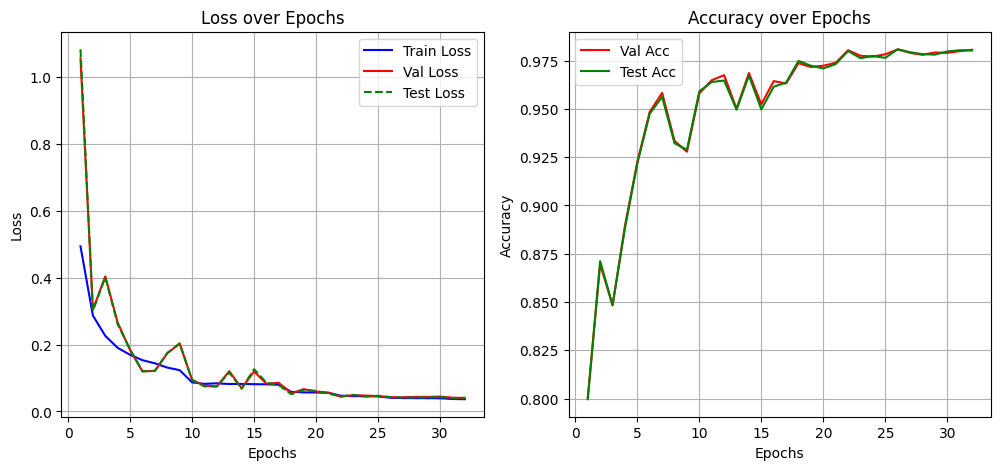

Results logged to /Storage/Files/practicalML/gitlab/practicalml/training_data/model_results.xlsx
Memory cleaned up.

TRAINING MODEL: VGG16
Initializing VGG16 (SCRATCH - No Pre-training)...
Starting training for 50 epochs (LR=0.01, AMP=False, Batch=128)...


Ep 1/50 [Train]:   0%|          | 0/2206 [00:00<?, ?it/s]

  [DEBUG] Input Batch Shape: torch.Size([80, 1, 224, 224])
Ep 1/50 | TrnLoss: 0.8595 Acc: 0.6124 | ValLoss: 0.4984 Acc: 0.8024 | TstLoss: 0.4952 Acc: 0.8046 | LR: 0.010000 [Saved Best to final_cnn_VGG16_best.pth]


Ep 2/50 [Train]:   0%|          | 0/2206 [00:00<?, ?it/s]

Ep 2/50 | TrnLoss: 0.4135 Acc: 0.8474 | ValLoss: 0.3263 Acc: 0.8645 | TstLoss: 0.3206 Acc: 0.8676 | LR: 0.010000 [Saved Best to final_cnn_VGG16_best.pth]


...

Ep 27/50 | TrnLoss: 0.0446 Acc: 0.9809 | ValLoss: 0.0476 Acc: 0.9771 | TstLoss: 0.0476 Acc: 0.9770 | LR: 0.001250 


Ep 28/50 [Train]:   0%|          | 0/2206 [00:00<?, ?it/s]

Ep 28/50 | TrnLoss: 0.0448 Acc: 0.9806 | ValLoss: 0.0454 Acc: 0.9779 | TstLoss: 0.0464 Acc: 0.9777 | LR: 0.001250 


Ep 29/50 [Train]:   0%|          | 0/2206 [00:00<?, ?it/s]

Ep 29/50 | TrnLoss: 0.0448 Acc: 0.9809 | ValLoss: 0.0469 Acc: 0.9791 | TstLoss: 0.0454 Acc: 0.9798 | LR: 0.001250 

Early stopping triggered after 6 epochs with no improvement.
Graphs saved to /Storage/Files/practicalML/gitlab/practicalml/training_data/VGG16_graphs_20251212_174046.png


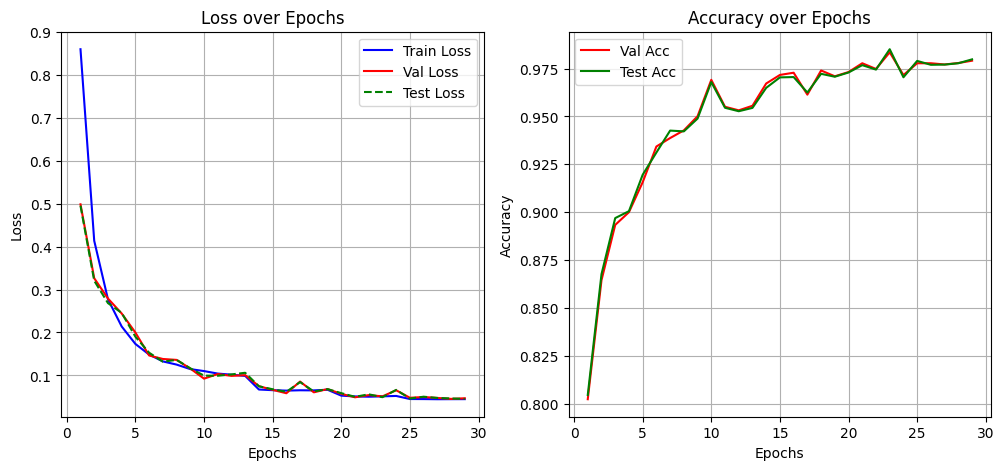

Results logged to /Storage/Files/practicalML/gitlab/practicalml/training_data/model_results.xlsx
Memory cleaned up.


In [9]:
import gc
if 'trainloader' in locals():
    models_to_train = ['DenseNet121', 'VGG16']
    
    dataset_info = {
        'num_classes': NUM_CLASSES,
        'channels': COLOR_CHANNELS
    }
    
    for model_name in models_to_train:
        # Cleanup Start
        torch.cuda.empty_cache()
        gc.collect()
        
        print(f"\n{'='*40}")
        print(f"TRAINING MODEL: {model_name}")
        print(f"{'='*40}")
        
        model = None
        try:
            # 1. Instantiate Model
            model = get_model(model_name, NUM_CLASSES, COLOR_CHANNELS, device)
            
            # 2. Train (Pass custom save name)
            save_filename = f"final_cnn_{model_name}_best.pth"
            history = train_model_final(
                model, 
                trainloader, 
                valloader, 
                testloader, 
                num_epochs=50,
                patience=6,
                save_name=save_filename
            )
            
            train_hist, val_loss_hist, val_acc_hist, test_loss_hist, test_acc_hist, best_acc = history
            
            # 3. Log Results
            save_results_and_graphs(
                (train_hist, val_loss_hist, val_acc_hist, test_loss_hist, test_acc_hist),
                best_acc,
                len(train_hist),
                dataset_info,
                model_name=model_name
            )
            
        except Exception as e:
            print(f"FAILED to train {model_name}: {e}")
            import traceback
            traceback.print_exc()
            
        finally:
            # Cleanup Memory
            if model is not None:
                del model
            gc.collect()
            torch.cuda.empty_cache()
            print("Memory cleaned up.")

else:
    print("DataLoaders not defined. Run setup cell first.")



TRAINING MODEL: EfficientNetV2
Initializing EfficientNetV2 (SCRATCH - No Pre-training)...
Starting training for 50 epochs (LR=0.01, AMP=False, Batch=128)...


Ep 1/50 [Train]:   0%|          | 0/2207 [00:00<?, ?it/s]

  [DEBUG] Input Batch Shape: torch.Size([80, 1, 224, 224])
Ep 1/50 | TrnLoss: 0.5772 Acc: 0.7680 | ValLoss: 0.4249 Acc: 0.8446 | TstLoss: 0.4175 Acc: 0.8449 | LR: 0.010000 [Saved Best to final_cnn_EfficientNetV2_best.pth]


Ep 2/50 [Train]:   0%|          | 0/2207 [00:00<?, ?it/s]

Ep 2/50 | TrnLoss: 0.3129 Acc: 0.8803 | ValLoss: 0.2925 Acc: 0.8822 | TstLoss: 0.2847 Acc: 0.8847 | LR: 0.010000 [Saved Best to final_cnn_EfficientNetV2_best.pth]


...

Ep 26/50 | TrnLoss: 0.0549 Acc: 0.9774 | ValLoss: 0.0471 Acc: 0.9758 | TstLoss: 0.0502 Acc: 0.9759 | LR: 0.000625 


Ep 27/50 [Train]:   0%|          | 0/2207 [00:00<?, ?it/s]

Ep 27/50 | TrnLoss: 0.0536 Acc: 0.9777 | ValLoss: 0.0454 Acc: 0.9809 | TstLoss: 0.0471 Acc: 0.9809 | LR: 0.000625 


Ep 28/50 [Train]:   0%|          | 0/2207 [00:00<?, ?it/s]

Ep 28/50 | TrnLoss: 0.0541 Acc: 0.9775 | ValLoss: 0.0498 Acc: 0.9847 | TstLoss: 0.0502 Acc: 0.9839 | LR: 0.000625 

Early stopping triggered after 6 epochs with no improvement.
Graphs saved to /Storage/Files/practicalML/gitlab/practicalml/training_data/EfficientNetV2_graphs_20251211_121128.png


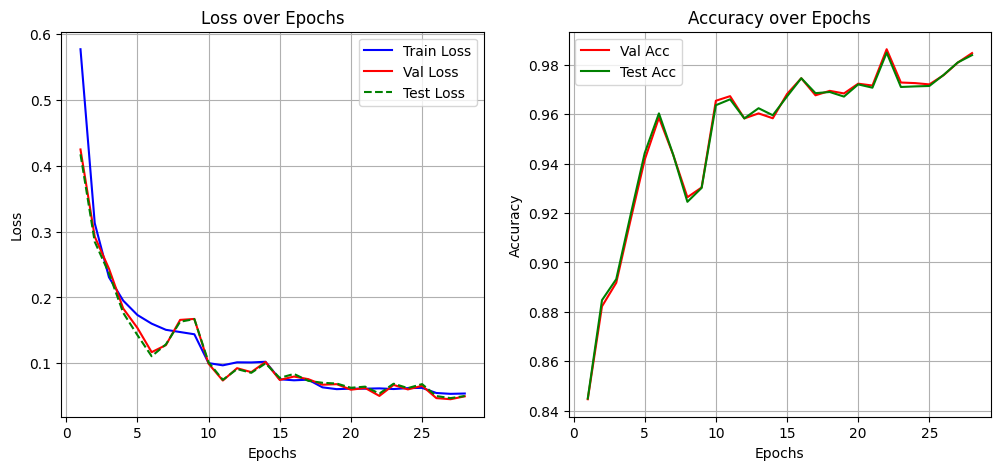

Results logged to /Storage/Files/practicalML/gitlab/practicalml/training_data/model_results.xlsx
Memory cleaned up.


In [9]:
# --- MAIN MULTI-MODEL LOOP ---
import gc
if 'trainloader' in locals():
    # models_to_train = ['MobileNetV2', 'EfficientNetV2', 'GoogLeNet', 'ResNet18', 'ShuffleNetV2']
    models_to_train = ['EfficientNetV2']
    
    dataset_info = {
        'num_classes': NUM_CLASSES,
        'channels': COLOR_CHANNELS
    }
    
    for model_name in models_to_train:
        # Cleanup Start
        torch.cuda.empty_cache()
        gc.collect()
        
        print(f"\n{'='*40}")
        print(f"TRAINING MODEL: {model_name}")
        print(f"{'='*40}")
        
        model = None
        try:
            # 1. Instantiate Model
            model = get_model(model_name, NUM_CLASSES, COLOR_CHANNELS, device)
            
            # 2. Train (Pass custom save name)
            save_filename = f"final_cnn_{model_name}_best.pth"
            history = train_model_final(
                model, 
                trainloader, 
                valloader, 
                testloader, 
                num_epochs=50,
                patience=6,
                save_name=save_filename
            )
            
            train_hist, val_loss_hist, val_acc_hist, test_loss_hist, test_acc_hist, best_acc = history
            
            # 3. Log Results
            save_results_and_graphs(
                (train_hist, val_loss_hist, val_acc_hist, test_loss_hist, test_acc_hist),
                best_acc,
                len(train_hist),
                dataset_info,
                model_name=model_name
            )
            
        except Exception as e:
            print(f"FAILED to train {model_name}: {e}")
            import traceback
            traceback.print_exc()
            
        finally:
            # Cleanup Memory
            if model is not None:
                del model
            gc.collect()
            torch.cuda.empty_cache()
            print("Memory cleaned up.")

else:
    print("DataLoaders not defined. Run setup cell first.")


TRAINING MODEL: MobileNetV2
Initializing MobileNetV2 (SCRATCH - No Pre-training)...
Starting training for 50 epochs (LR=0.01, AMP=False, Batch=128)...


Ep 1/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

  [DEBUG] Input Batch Shape: torch.Size([128, 1, 224, 224])
Ep 1/50 | TrnLoss: 0.5403 Acc: 0.7936 | ValLoss: 0.3229 Acc: 0.8760 | TstLoss: 0.3274 Acc: 0.8773 | LR: 0.010000 [Saved Best to final_cnn_MobileNetV2_best.pth]


Ep 2/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 2/50 | TrnLoss: 0.3098 Acc: 0.8831 | ValLoss: 0.2617 Acc: 0.8941 | TstLoss: 0.2617 Acc: 0.8922 | LR: 0.010000 [Saved Best to final_cnn_MobileNetV2_best.pth]


...

Ep 44/50 | TrnLoss: 0.0389 Acc: 0.9826 | ValLoss: 0.0481 Acc: 0.9758 | TstLoss: 0.0419 Acc: 0.9784 | LR: 0.000156 


Ep 45/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 45/50 | TrnLoss: 0.0386 Acc: 0.9827 | ValLoss: 0.0463 Acc: 0.9775 | TstLoss: 0.0433 Acc: 0.9787 | LR: 0.000156 


Ep 46/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 46/50 | TrnLoss: 0.0381 Acc: 0.9827 | ValLoss: 0.0469 Acc: 0.9764 | TstLoss: 0.0403 Acc: 0.9782 | LR: 0.000078 

Early stopping triggered after 6 epochs with no improvement.
Graphs saved to /Storage/Files/practicalML/gitlab/practicalml/training_data/MobileNetV2_graphs_20251211_010323.png


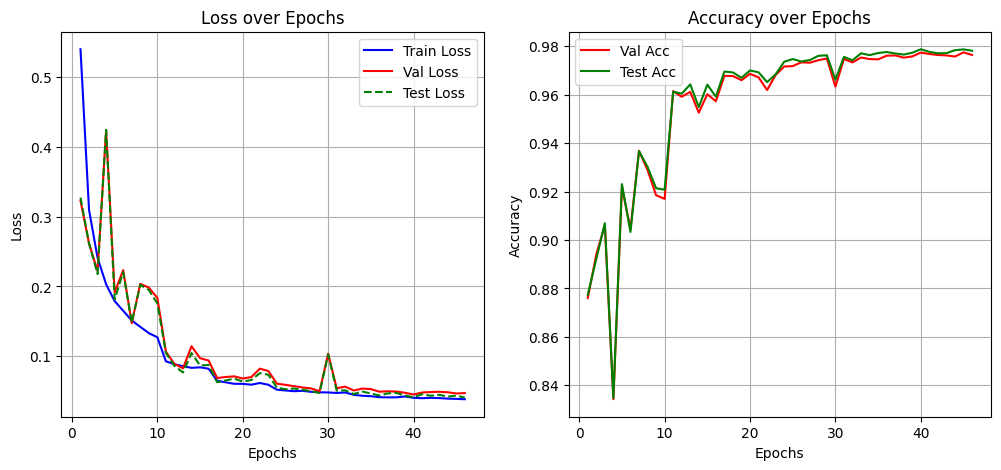

Results logged to /Storage/Files/practicalML/gitlab/practicalml/training_data/model_results.xlsx
Memory cleaned up.

TRAINING MODEL: EfficientNetV2
Initializing EfficientNetV2 (SCRATCH - No Pre-training)...
Starting training for 50 epochs (LR=0.01, AMP=False, Batch=128)...


Ep 1/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

  [DEBUG] Input Batch Shape: torch.Size([128, 1, 224, 224])
FAILED to train EfficientNetV2: CUDA out of memory. Tried to allocate 92.00 MiB. GPU 0 has a total capacity of 15.44 GiB of which 142.12 MiB is free. Including non-PyTorch memory, this process has 14.73 GiB memory in use. Of the allocated memory 14.36 GiB is allocated by PyTorch, and 40.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Traceback (most recent call last):
  File "/tmp/ipykernel_7209/3776195860.py", line 27, in <module>
    history = train_model_final(
              ^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_7209/283805395.py", line 30, in train_model_final
    outputs = model(imgs)
              ^^^^^^^^^^^
  File "/home/tim/miniconda3/envs/practicalML/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tim/miniconda3/envs/practicalML/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1784, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tim/miniconda3/envs/practicalML/lib/python3.12/site-packages/torchvision/models/efficientnet.py", line 344, in forward
    return self._forward_impl(x)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/tim/miniconda3/envs/practicalML/lib/python3.12/site-packages

Memory cleaned up.

TRAINING MODEL: GoogLeNet
Initializing GoogLeNet (SCRATCH - No Pre-training)...
Starting training for 50 epochs (LR=0.01, AMP=False, Batch=128)...


...

Ep 48/50 | TrnLoss: 0.0352 Acc: 0.9847 | ValLoss: 0.0406 Acc: 0.9813 | TstLoss: 0.0376 Acc: 0.9827 | LR: 0.000156 


Ep 49/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 49/50 | TrnLoss: 0.0353 Acc: 0.9845 | ValLoss: 0.0415 Acc: 0.9813 | TstLoss: 0.0379 Acc: 0.9823 | LR: 0.000156 


Ep 50/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 50/50 | TrnLoss: 0.0359 Acc: 0.9844 | ValLoss: 0.0453 Acc: 0.9793 | TstLoss: 0.0432 Acc: 0.9805 | LR: 0.000078 
Graphs saved to /Storage/Files/practicalML/gitlab/practicalml/training_data/GoogLeNet_graphs_20251211_024728.png


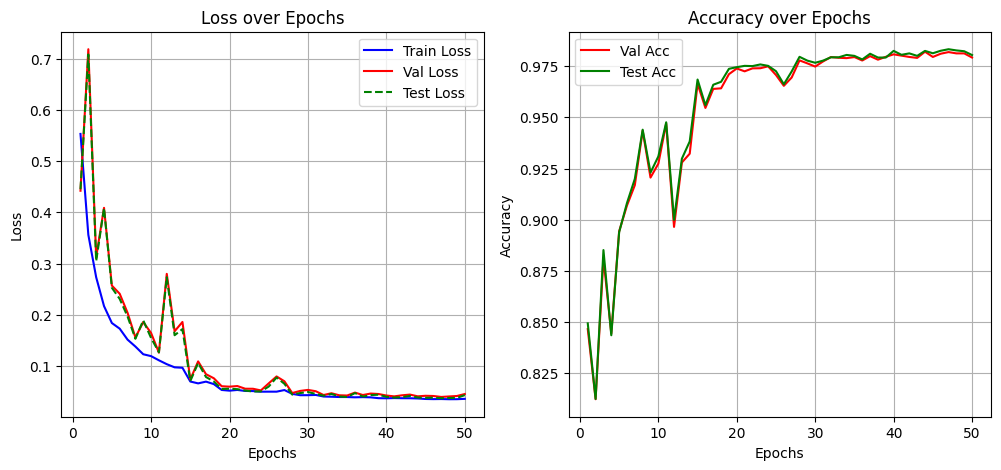

Results logged to /Storage/Files/practicalML/gitlab/practicalml/training_data/model_results.xlsx
Memory cleaned up.

TRAINING MODEL: ResNet18
Initializing ResNet18 (SCRATCH - No Pre-training)...
Starting training for 50 epochs (LR=0.01, AMP=False, Batch=128)...


Ep 1/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

  [DEBUG] Input Batch Shape: torch.Size([128, 1, 224, 224])
Ep 1/50 | TrnLoss: 0.5590 Acc: 0.7855 | ValLoss: 4.1797 Acc: 0.7360 | TstLoss: 4.1477 Acc: 0.7383 | LR: 0.010000 [Saved Best to final_cnn_ResNet18_best.pth]


Ep 2/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 2/50 | TrnLoss: 0.3673 Acc: 0.8636 | ValLoss: 0.4192 Acc: 0.8453 | TstLoss: 0.4225 Acc: 0.8467 | LR: 0.010000 [Saved Best to final_cnn_ResNet18_best.pth]


...

Ep 21/50 | TrnLoss: 0.0692 Acc: 0.9719 | ValLoss: 0.0986 Acc: 0.9583 | TstLoss: 0.0944 Acc: 0.9584 | LR: 0.005000 


Ep 22/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 22/50 | TrnLoss: 0.0708 Acc: 0.9712 | ValLoss: 0.0742 Acc: 0.9662 | TstLoss: 0.0650 Acc: 0.9703 | LR: 0.005000 


Ep 23/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 23/50 | TrnLoss: 0.0700 Acc: 0.9716 | ValLoss: 0.0839 Acc: 0.9694 | TstLoss: 0.0811 Acc: 0.9705 | LR: 0.005000 

Early stopping triggered after 6 epochs with no improvement.
Graphs saved to /Storage/Files/practicalML/gitlab/practicalml/training_data/ResNet18_graphs_20251211_032537.png


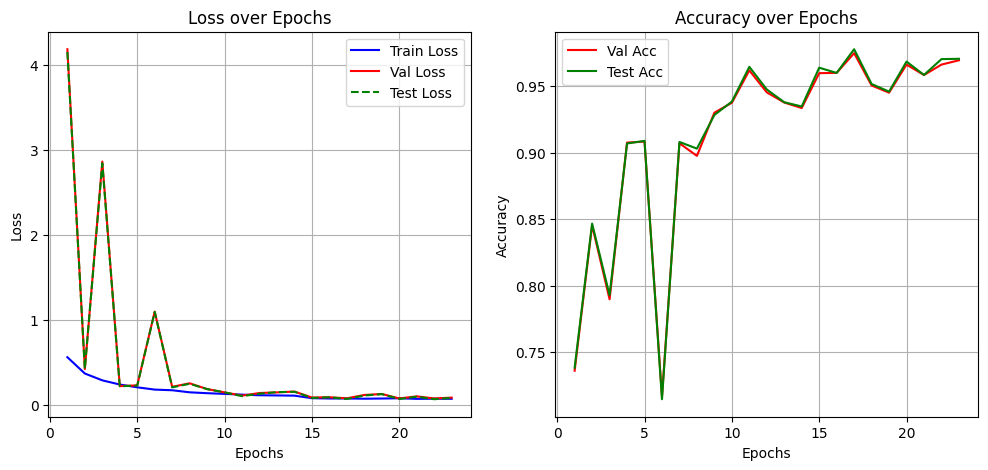

Results logged to /Storage/Files/practicalML/gitlab/practicalml/training_data/model_results.xlsx
Memory cleaned up.

TRAINING MODEL: ShuffleNetV2
Initializing ShuffleNetV2 (SCRATCH - No Pre-training)...
Starting training for 50 epochs (LR=0.01, AMP=False, Batch=128)...


Ep 1/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

  [DEBUG] Input Batch Shape: torch.Size([128, 1, 224, 224])
Ep 1/50 | TrnLoss: 0.6316 Acc: 0.7509 | ValLoss: 0.4155 Acc: 0.8493 | TstLoss: 0.4213 Acc: 0.8466 | LR: 0.010000 [Saved Best to final_cnn_ShuffleNetV2_best.pth]


Ep 2/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 2/50 | TrnLoss: 0.3691 Acc: 0.8631 | ValLoss: 0.3733 Acc: 0.8569 | TstLoss: 0.3734 Acc: 0.8575 | LR: 0.010000 [Saved Best to final_cnn_ShuffleNetV2_best.pth]


...

Ep 18/50 | TrnLoss: 0.1032 Acc: 0.9584 | ValLoss: 0.1286 Acc: 0.9431 | TstLoss: 0.1193 Acc: 0.9453 | LR: 0.005000 


Ep 19/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 19/50 | TrnLoss: 0.1002 Acc: 0.9593 | ValLoss: 0.1661 Acc: 0.9320 | TstLoss: 0.1555 Acc: 0.9359 | LR: 0.005000 


Ep 20/50 [Train]:   0%|          | 0/1377 [00:00<?, ?it/s]

Ep 20/50 | TrnLoss: 0.1033 Acc: 0.9582 | ValLoss: 0.1257 Acc: 0.9438 | TstLoss: 0.1173 Acc: 0.9488 | LR: 0.002500 

Early stopping triggered after 6 epochs with no improvement.
Graphs saved to /Storage/Files/practicalML/gitlab/practicalml/training_data/ShuffleNetV2_graphs_20251211_034038.png


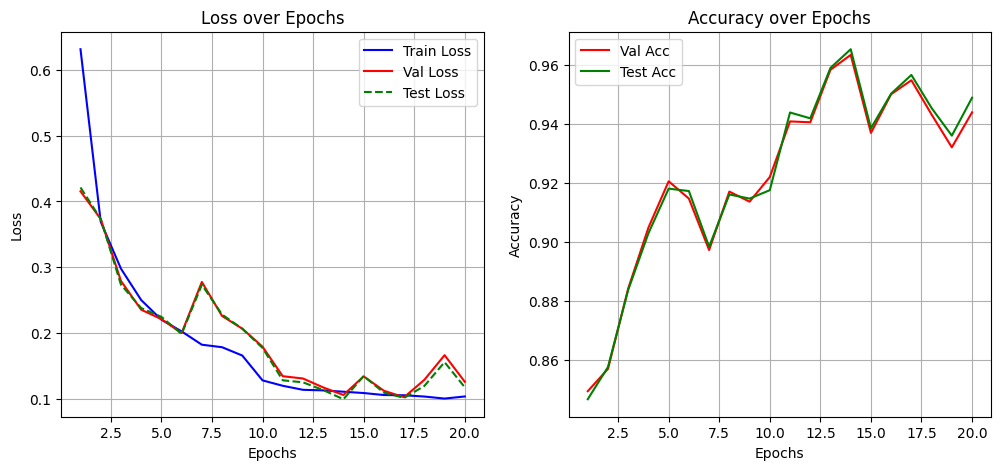

Results logged to /Storage/Files/practicalML/gitlab/practicalml/training_data/model_results.xlsx
Memory cleaned up.


In [ ]:
# --- MAIN MULTI-MODEL LOOP ---
import gc
if 'trainloader' in locals():
    # models_to_train = ['MobileNetV2', 'EfficientNetV2', 'GoogLeNet', 'ResNet18', 'ShuffleNetV2']
    models_to_train = ['EfficientNetV2']
    
    dataset_info = {
        'num_classes': NUM_CLASSES,
        'channels': COLOR_CHANNELS
    }
    
    for model_name in models_to_train:
        # Cleanup Start
        torch.cuda.empty_cache()
        gc.collect()
        
        print(f"\n{'='*40}")
        print(f"TRAINING MODEL: {model_name}")
        print(f"{'='*40}")
        
        model = None
        try:
            # 1. Instantiate Model
            model = get_model(model_name, NUM_CLASSES, COLOR_CHANNELS, device)
            
            # 2. Train (Pass custom save name)
            save_filename = f"final_cnn_{model_name}_best.pth"
            history = train_model_final(
                model, 
                trainloader, 
                valloader, 
                testloader, 
                num_epochs=50,
                patience=6,
                save_name=save_filename
            )
            
            train_hist, val_loss_hist, val_acc_hist, test_loss_hist, test_acc_hist, best_acc = history
            
            # 3. Log Results
            save_results_and_graphs(
                (train_hist, val_loss_hist, val_acc_hist, test_loss_hist, test_acc_hist),
                best_acc,
                len(train_hist),
                dataset_info,
                model_name=model_name
            )
            
        except Exception as e:
            print(f"FAILED to train {model_name}: {e}")
            import traceback
            traceback.print_exc()
            
        finally:
            # Cleanup Memory
            if model is not None:
                del model
            gc.collect()
            torch.cuda.empty_cache()
            print("Memory cleaned up.")

else:
    print("DataLoaders not defined. Run setup cell first.")